g# Collaborative Filtering with SVD - MovieLens 100k
Builds and evaluates a recommender with the **Surprise** library, following the project brief:

1. Load the cleaned data (from `eda_recsys.ipynb`) into Surprise's `Dataset`
2. 75/25 train/test split
3. Baselines + SVD model, evaluated with **RMSE** (and MAE)
4. Hyper-parameter tuning with `GridSearchCV`
5. Predictions for individual user-movie pairs
6. **Top-N recommendations** for every user
7. Ranking metrics (Precision@10 / Recall@10) and a demographic **bias check** for the ethics section

In [1]:
import warnings, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from IPython.display import display, Markdown

from surprise import SVD, BaselineOnly, Dataset, Reader, accuracy, dump
from surprise.model_selection import train_test_split, GridSearchCV, KFold

warnings.filterwarnings('ignore')
%matplotlib inline

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd()
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)

ModuleNotFoundError: No module named 'numpy'

## 1. Load cleaned data into Surprise

In [ ]:
ratings = pd.read_csv(ROOT / 'ratings_clean.csv')
movies  = pd.read_csv(ROOT / 'movies_clean.csv')
users   = pd.read_csv(ROOT / 'users_clean.csv')
title_of = movies.set_index('item_id')['title'].to_dict()

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'item_id', 'rating']], reader)
print(f"{len(ratings):,} ratings | {ratings.user_id.nunique()} users | {ratings.item_id.nunique()} movies")

100,000 ratings | 943 users | 1682 movies


## 2. Train / test split (75 / 25)

In [ ]:
trainset, testset = train_test_split(data, test_size=0.25, random_state=SEED)
print(f"train: {trainset.n_ratings:,} ratings ({trainset.n_users} users, {trainset.n_items} items)")
print(f"test : {len(testset):,} ratings")

train: 75,000 ratings (943 users, 1644 items)
test : 25,000 ratings


## 3. Baselines (context for what a good RMSE looks like)
A model is only useful if it beats trivial predictors: always guessing the global mean, and the bias-only `BaselineOnly` model (global mean + user bias + item bias).

In [ ]:
mu = trainset.global_mean
y_true = np.array([r for (_, _, r) in testset])
rmse_global = float(np.sqrt(np.mean((y_true - mu) ** 2)))
mae_global  = float(np.mean(np.abs(y_true - mu)))
print(f"Global-mean baseline (mu = {mu:.3f}):  RMSE = {rmse_global:.4f}   MAE = {mae_global:.4f}")

bl = BaselineOnly(verbose=False)
bl.fit(trainset)
pred_bl = bl.test(testset)
rmse_bl = accuracy.rmse(pred_bl)
mae_bl  = accuracy.mae(pred_bl)

Global-mean baseline (mu = 3.531):  RMSE = 1.1297   MAE = 0.9479
RMSE: 0.9474
MAE:  0.7511


## 4. SVD model (default hyper-parameters)

In [ ]:
svd_default = SVD(random_state=SEED)      # n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02
t0 = time.time()
svd_default.fit(trainset)
print(f"fit time: {time.time() - t0:.1f}s")

pred_default = svd_default.test(testset)
rmse_default = accuracy.rmse(pred_default)
mae_default  = accuracy.mae(pred_default)

fit time: 0.5s
RMSE: 0.9396
MAE:  0.7408


## 5. Hyper-parameter tuning with `GridSearchCV`
**Stage 1** uses the exact grid from the brief (`n_factors`, `n_epochs`, `lr_all`). **Stage 2** then tunes the regularisation strength `reg_all` around the stage-1 winner.

> Note: tuning is run on the **training portion only**. The brief's snippet fits `GridSearchCV` on the whole dataset, which would let the 25% test set influence which hyper-parameters get picked. Here the test set stays untouched until the final evaluation.

In [ ]:
# rebuild a Dataset from the training ratings only (no test leakage)
train_rows = [(trainset.to_raw_uid(u), trainset.to_raw_iid(i), r) for u, i, r in trainset.all_ratings()]
train_df = pd.DataFrame(train_rows, columns=['user_id', 'item_id', 'rating'])
data_train = Dataset.load_from_df(train_df, reader)

param_grid = {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005],
              'random_state': [SEED]}
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=KFold(n_splits=3, random_state=SEED, shuffle=True), n_jobs=1)

t0 = time.time()
gs.fit(data_train)
print(f"stage 1 done in {time.time() - t0:.0f}s")
print("best CV RMSE  :", round(gs.best_score['rmse'], 4))
print("best params   :", {k: v for k, v in gs.best_params['rmse'].items() if k != 'random_state'})

def show_cv(gsearch):
    t = pd.DataFrame(gsearch.cv_results)[['params', 'mean_test_rmse', 'std_test_rmse',
                                          'mean_test_mae', 'mean_fit_time', 'rank_test_rmse']]
    t['params'] = t['params'].apply(lambda d: {k: v for k, v in d.items() if k != 'random_state'})
    return t.sort_values('rank_test_rmse').round(4).reset_index(drop=True)

cv_stage1 = show_cv(gs)
cv_stage1

stage 1 done in 10s
best CV RMSE  : 0.9534
best params   : {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005}


,params,mean_test_rmse,std_test_rmse,mean_test_mae,mean_fit_time,rank_test_rmse
0,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",0.9534,0.0020,0.7540,0.2100,1
1,"{'n_factors': 50, 'n_epochs': 40, 'lr_all': 0....",0.9540,0.0021,0.7550,0.4431,2
2,"{'n_factors': 100, 'n_epochs': 40, 'lr_all': 0...",0.9579,0.0026,0.7578,0.4640,3
3,"{'n_factors': 100, 'n_epochs': 20, 'lr_all': 0...",0.9581,0.0026,0.7573,0.2242,4
4,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",0.9606,0.0023,0.7623,0.1909,5
5,"{'n_factors': 100, 'n_epochs': 20, 'lr_all': 0...",0.9635,0.0027,0.7644,0.2190,6
6,"{'n_factors': 50, 'n_epochs': 40, 'lr_all': 0....",0.9733,0.0022,0.7654,0.3590,7
7,"{'n_factors': 100, 'n_epochs': 40, 'lr_all': 0...",0.9766,0.0029,0.7687,0.4295,8


In [ ]:
best1 = dict(gs.best_params['rmse'])
grid2 = {**{k: [v] for k, v in best1.items()}, 'reg_all': [0.02, 0.04, 0.06, 0.1]}
gs2 = GridSearchCV(SVD, grid2, measures=['rmse', 'mae'], cv=KFold(n_splits=3, random_state=SEED, shuffle=True), n_jobs=1)

t0 = time.time()
gs2.fit(data_train)
print(f"stage 2 done in {time.time() - t0:.0f}s")
print("best CV RMSE  :", round(gs2.best_score['rmse'], 4))
best_params = dict(gs2.best_params['rmse'])
print("FINAL params  :", {k: v for k, v in best_params.items() if k != 'random_state'})

cv_stage2 = show_cv(gs2)
cv_stage2

stage 2 done in 3s
best CV RMSE  : 0.9501
FINAL params  : {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.06}


,params,mean_test_rmse,std_test_rmse,mean_test_mae,mean_fit_time,rank_test_rmse
0,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",0.9501,0.0021,0.7530,0.1525,1
1,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",0.9504,0.0022,0.7545,0.1479,2
2,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",0.9510,0.0020,0.7529,0.1543,3
3,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",0.9534,0.0020,0.7540,0.1633,4


## 6. Final model - evaluation on the held-out test set

In [ ]:
svd_best = SVD(**best_params)
svd_best.fit(trainset)
pred_best = svd_best.test(testset)
rmse_best = accuracy.rmse(pred_best)
mae_best  = accuracy.mae(pred_best)

comparison = pd.DataFrame({
    'Model': ['Global mean', 'BaselineOnly (biases)', 'SVD (default)', 'SVD (tuned)'],
    'RMSE': [rmse_global, rmse_bl, rmse_default, rmse_best],
    'MAE':  [mae_global,  mae_bl,  mae_default,  mae_best],
}).round(4)
comparison['RMSE improvement vs global mean'] = ((rmse_global - comparison['RMSE']) / rmse_global * 100).round(1).astype(str) + '%'
comparison

RMSE: 0.9393
MAE:  0.7428


,Model,RMSE,MAE,RMSE improvement vs global mean
0,Global mean,1.1297,0.9479,-0.0%
1,BaselineOnly (biases),0.9474,0.7511,16.1%
2,SVD (default),0.9396,0.7408,16.8%
3,SVD (tuned),0.9393,0.7428,16.9%


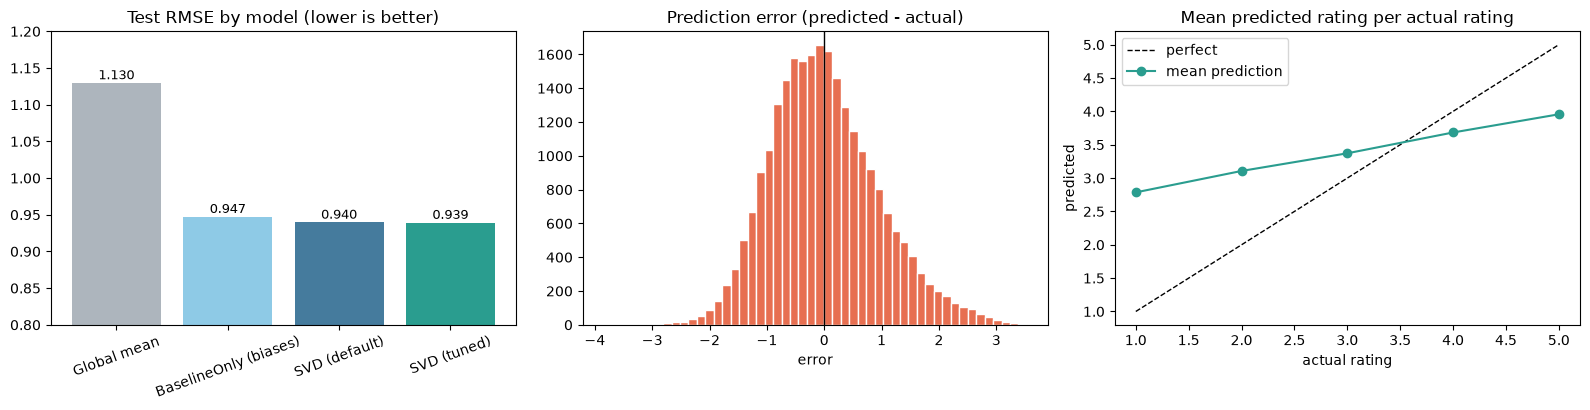

In [ ]:
errors = np.array([p.est - p.r_ui for p in pred_best])
actual = np.array([p.r_ui for p in pred_best])
est    = np.array([p.est for p in pred_best])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].bar(comparison['Model'], comparison['RMSE'], color=['#adb5bd', '#8ecae6', '#457b9d', '#2a9d8f'])
axes[0].set_title('Test RMSE by model (lower is better)'); axes[0].set_ylim(0.8, 1.2)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(comparison['RMSE']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

axes[1].hist(errors, bins=50, color='#e76f51', edgecolor='white')
axes[1].axvline(0, color='k', lw=1)
axes[1].set_title('Prediction error (predicted - actual)'); axes[1].set_xlabel('error')

means = pd.DataFrame({'actual': actual, 'est': est}).groupby('actual')['est'].mean()
axes[2].plot([1, 5], [1, 5], 'k--', lw=1, label='perfect')
axes[2].plot(means.index, means.values, 'o-', color='#2a9d8f', label='mean prediction')
axes[2].set_title('Mean predicted rating per actual rating')
axes[2].set_xlabel('actual rating'); axes[2].set_ylabel('predicted'); axes[2].legend()
plt.tight_layout()
plt.savefig(FIG / '05_model_evaluation.png', dpi=110)
plt.show()

## 7. Making predictions
**a) One user-movie pair the user has already rated** (so we can compare with the truth):

In [ ]:
uid, iid = 196, 242
true_r = ratings.loc[(ratings.user_id == uid) & (ratings.item_id == iid), 'rating'].iloc[0]
print(f"Movie: {title_of[iid]}")
p = svd_best.predict(uid, iid, r_ui=true_r, verbose=True)

Movie: Kolya (1996)
user: 196        item: 242        r_ui = 3.00   est = 3.95   {'was_impossible': False}


**b) A movie the user has *not* rated** - this is the real recommendation use-case (there is no ground truth, only the model's estimate):

In [ ]:
seen = set(ratings.loc[ratings.user_id == uid, 'item_id'])
popular_unseen = [i for i in ratings.item_id.value_counts().index if i not in seen][:5]
for iid_ in popular_unseen:
    p = svd_best.predict(uid, iid_)
    print(f"user {uid} -> {title_of[iid_][:40]:<42} predicted rating: {p.est:.2f}")

user 196 -> Star Wars (1977)                           predicted rating: 4.29
user 196 -> Contact (1997)                             predicted rating: 3.84
user 196 -> Fargo (1996)                               predicted rating: 4.11
user 196 -> Return of the Jedi (1983)                  predicted rating: 4.01
user 196 -> Liar Liar (1997)                           predicted rating: 3.26


**c) A random sample of test-set predictions vs. the actual ratings:**

In [ ]:
sample = pd.DataFrame([{
    'user_id': p.uid, 'movie': title_of[p.iid][:38], 'actual': p.r_ui,
    'predicted': round(p.est, 2), 'abs_error': round(abs(p.est - p.r_ui), 2)}
    for p in pred_best]).sample(15, random_state=SEED).reset_index(drop=True)
sample

,user_id,movie,actual,predicted,abs_error
0,293,"Manchurian Candidate, The (1962)",4.0,3.77,0.23
1,221,Spawn (1997),3.0,2.76,0.24
2,587,She's So Lovely (1997),1.0,2.53,1.53
3,648,"Good, The Bad and The Ugly, The (1966)",5.0,3.73,1.27
4,343,Blade Runner (1982),3.0,4.46,1.46
5,943,Rumble in the Bronx (1995),4.0,3.49,0.51
6,815,Searching for Bobby Fischer (1993),5.0,4.09,0.91
7,894,French Twist (Gazon maudit) (1995),3.0,3.29,0.29
8,883,Everyone Says I Love You (1996),3.0,3.57,0.57
9,64,Muriel's Wedding (1994),4.0,3.43,0.57


## 8. Top-N recommendations for every user
`get_top_n` is the function from the brief. It is fed with predictions for every movie a user has **not** rated in the training set (Surprise's "anti-testset"), processed in batches of users to keep memory low.

In [ ]:
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

def recommend_all(model, trainset, n=10, batch=100):
    fill = trainset.global_mean
    all_inner_items = list(trainset.all_items())
    raw_uids = [trainset.to_raw_uid(u) for u in trainset.all_users()]
    result = {}
    for start in range(0, len(raw_uids), batch):
        anti = []
        for uid in raw_uids[start:start + batch]:
            rated = {j for (j, _) in trainset.ur[trainset.to_inner_uid(uid)]}
            anti.extend((uid, trainset.to_raw_iid(i), fill) for i in all_inner_items if i not in rated)
        result.update(get_top_n(model.test(anti), n=n))
    return result

t0 = time.time()
top_n = recommend_all(svd_best, trainset, n=10)
print(f"generated top-10 lists for {len(top_n)} users in {time.time() - t0:.0f}s")

generated top-10 lists for 943 users in 4s


In [ ]:
n_train_ratings = train_df.groupby('item_id').size()

def show_recs(uid, n=10):
    liked = (train_df[(train_df.user_id == uid) & (train_df.rating == 5)]
             .item_id.map(title_of).head(5).tolist())
    print(f"USER {uid}  -  some movies they rated 5 in training: {liked}\n")
    for rank, (iid, est) in enumerate(top_n[uid][:n], 1):
        print(f"  {rank:>2}. {title_of[iid][:45]:<47} predicted {est:.2f}   "
              f"({n_train_ratings.get(iid, 0)} training ratings)")
    print()

for u in (1, 196, 500):
    show_recs(u)

USER 1  -  some movies they rated 5 in training: ['Fargo (1996)', 'Return of the Jedi (1983)', 'Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)', 'Contact (1997)', 'Breaking the Waves (1996)']

   1. Casablanca (1942)                               predicted 4.58   (178 training ratings)
   2. Close Shave, A (1995)                           predicted 4.58   (89 training ratings)
   3. Third Man, The (1949)                           predicted 4.53   (45 training ratings)
   4. Schindler's List (1993)                         predicted 4.46   (234 training ratings)
   5. Raise the Red Lantern (1991)                    predicted 4.45   (43 training ratings)
   6. North by Northwest (1959)                       predicted 4.42   (134 training ratings)
   7. Secrets & Lies (1996)                           predicted 4.40   (124 training ratings)
   8. Ran (1985)                                      predicted 4.37   (50 training ratings)
   9. Bridge on the River Kwai, The (1957)           

In [ ]:
rec_rows = [{'user_id': uid, 'rank': r, 'item_id': iid, 'title': title_of[iid],
             'predicted_rating': round(est, 3), 'n_training_ratings': int(n_train_ratings.get(iid, 0))}
            for uid, lst in top_n.items() for r, (iid, est) in enumerate(lst, 1)]
recs_df = pd.DataFrame(rec_rows).sort_values(['user_id', 'rank'])
recs_df.to_csv(ROOT / 'top10_recommendations.csv', index=False)
print(f"saved top10_recommendations.csv  ({len(recs_df):,} rows = {recs_df.user_id.nunique()} users x 10)")

print("\nMost frequently recommended movies across all users:")
recs_df['title'].value_counts().head(8)

saved top10_recommendations.csv  (9,430 rows = 943 users x 10)

Most frequently recommended movies across all users:


title
Close Shave, A (1995)                                     854
Third Man, The (1949)                                     757
Casablanca (1942)                                         745
Shawshank Redemption, The (1994)                          703
Wrong Trousers, The (1993)                                697
Schindler's List (1993)                                   691
12 Angry Men (1957)                                       679
Wallace & Gromit: The Best of Aardman Animation (1996)    431
Name: count, dtype: int64

## 9. Ranking metrics - Precision@10 and Recall@10
RMSE measures how close the *rating* is; these measure whether the *top of the list* is good. A movie counts as relevant if its true rating is >= 4.

In [ ]:
def precision_recall_at_k(predictions, k=10, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions, recalls = {}, {}
    for uid, ur in user_est_true.items():
        ur.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum(true_r >= threshold for (_, true_r) in ur)
        n_rec_k = sum(est >= threshold for (est, _) in ur[:k])
        n_hit = sum((true_r >= threshold) and (est >= threshold) for (est, true_r) in ur[:k])
        precisions[uid] = n_hit / n_rec_k if n_rec_k else 0
        recalls[uid] = n_hit / n_rel if n_rel else 0
    return precisions, recalls

prec, rec = precision_recall_at_k(pred_best, k=10, threshold=4.0)
p_at_10 = float(np.mean(list(prec.values())))
r_at_10 = float(np.mean(list(rec.values())))
print(f"Precision@10 = {p_at_10:.3f}    Recall@10 = {r_at_10:.3f}    (users evaluated: {len(prec)})")

Precision@10 = 0.622    Recall@10 = 0.250    (users evaluated: 943)


## 10. Bias check (ethics: does the model work equally well for everyone?)
Test-set RMSE broken down by demographic group and by how popular a movie is.

In [ ]:
pred_df = pd.DataFrame([{'user_id': p.uid, 'item_id': p.iid, 'actual': p.r_ui, 'est': p.est}
                        for p in pred_best]).merge(users, on='user_id', how='left')
pred_df['sq_err'] = (pred_df['est'] - pred_df['actual']) ** 2
pred_df['age_group'] = pd.cut(pred_df['age'], [0, 20, 30, 40, 50, 100],
                              labels=['<=20', '21-30', '31-40', '41-50', '51+'])
pred_df['item_popularity'] = pd.cut(pred_df['item_id'].map(n_train_ratings).fillna(0),
                                    [-1, 10, 50, 150, 10000],
                                    labels=['0-10 ratings', '11-50', '51-150', '150+'])

def group_rmse(col):
    g = pred_df.groupby(col, observed=True)['sq_err'].agg(['mean', 'size'])
    return pd.DataFrame({'RMSE': np.sqrt(g['mean']).round(4), 'n_test_ratings': g['size']})

by_gender, by_age, by_pop = group_rmse('gender'), group_rmse('age_group'), group_rmse('item_popularity')
occ = group_rmse('occupation')
by_occ = occ[occ.n_test_ratings >= 300].sort_values('RMSE')

for name, t in [('GENDER', by_gender), ('AGE GROUP', by_age), ('MOVIE POPULARITY', by_pop)]:
    print(f"--- RMSE by {name} ---"); print(t.to_string()); print()
print("--- RMSE by OCCUPATION (>= 300 test ratings) ---"); print(by_occ.to_string())

--- RMSE by GENDER ---
          RMSE  n_test_ratings
gender                        
F       0.9799            6487
M       0.9246           18513

--- RMSE by AGE GROUP ---
             RMSE  n_test_ratings
age_group                        
<=20       0.9749            3076
21-30      0.9524            9857
31-40      0.9161            5927
41-50      0.9414            3798
51+        0.8892            2342

--- RMSE by MOVIE POPULARITY ---
                   RMSE  n_test_ratings
item_popularity                        
0-10 ratings     1.0704             964
11-50            0.9766            5164
51-150           0.9257           10535
150+             0.9162            8337

--- RMSE by OCCUPATION (>= 300 test ratings) ---
                 RMSE  n_test_ratings
occupation                           
retired        0.8309             413
engineer       0.8707            2064
librarian      0.8883            1313
lawyer         0.8950             342
scientist      0.8967             50

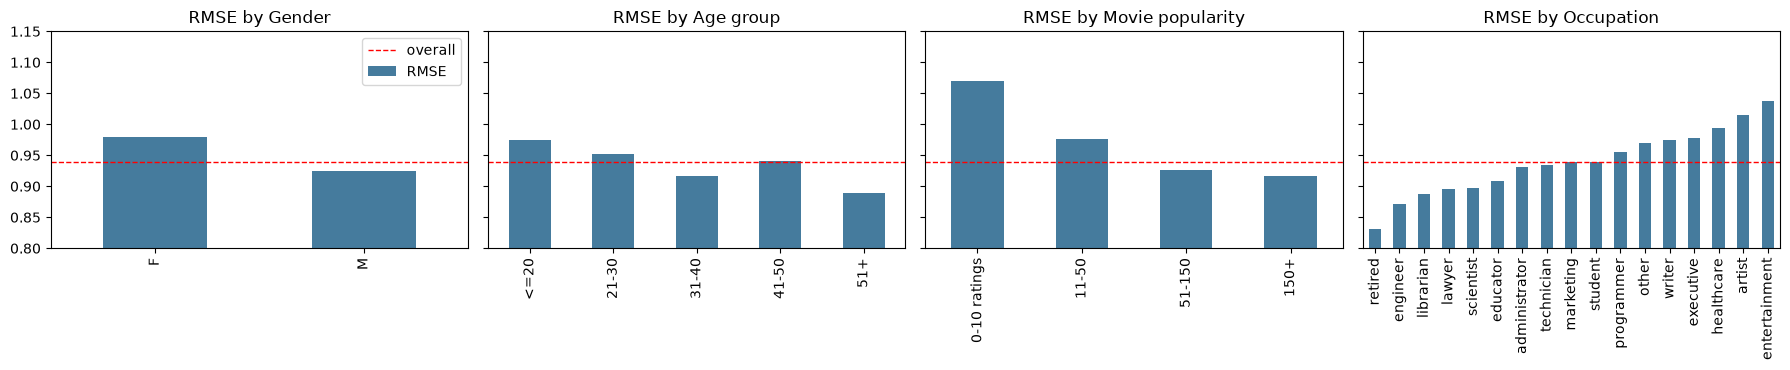

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
for ax, (t, title) in zip(axes, [(by_gender, 'Gender'), (by_age, 'Age group'),
                                 (by_pop, 'Movie popularity'), (by_occ, 'Occupation')]):
    t['RMSE'].plot(kind='bar', ax=ax, color='#457b9d')
    ax.axhline(rmse_best, color='r', ls='--', lw=1, label='overall')
    ax.set_title(f'RMSE by {title}'); ax.set_ylim(0.8, 1.15); ax.set_xlabel('')
axes[0].legend()
plt.tight_layout()
plt.savefig(FIG / '06_bias_check.png', dpi=110)
plt.show()

## 11. Save artifacts

In [ ]:
dump.dump(str(ROOT / 'svd_model.pkl'), algo=svd_best, predictions=pred_best)

results = {
    'split': {'train_ratings': int(trainset.n_ratings), 'test_ratings': int(len(testset)), 'seed': SEED},
    'rmse': {'global_mean': rmse_global, 'baseline_only': float(rmse_bl),
             'svd_default': float(rmse_default), 'svd_tuned': float(rmse_best)},
    'mae':  {'global_mean': mae_global, 'baseline_only': float(mae_bl),
             'svd_default': float(mae_default), 'svd_tuned': float(mae_best)},
    'best_params': {k: (float(v) if isinstance(v, float) else int(v)) for k, v in best_params.items()},
    'cv_best_rmse_stage1': float(gs.best_score['rmse']),
    'cv_best_rmse_stage2': float(gs2.best_score['rmse']),
    'precision_at_10': p_at_10, 'recall_at_10': r_at_10,
    'rmse_by_gender': by_gender['RMSE'].to_dict(),
    'rmse_by_age_group': {str(k): v for k, v in by_age['RMSE'].to_dict().items()},
    'rmse_by_item_popularity': {str(k): v for k, v in by_pop['RMSE'].to_dict().items()},
}
with open(ROOT / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("saved: svd_model.pkl, results.json, top10_recommendations.csv, figures/05-06")

saved: svd_model.pkl, results.json, top10_recommendations.csv, figures/05-06


In [ ]:
bp = {k: v for k, v in best_params.items() if k != 'random_state'}
display(Markdown(f"""## Summary
- **Data:** {len(ratings):,} ratings, split 75/25 with seed {SEED} ({trainset.n_ratings:,} train / {len(testset):,} test).
- **Baselines:** global-mean RMSE **{rmse_global:.4f}**; bias-only `BaselineOnly` RMSE **{rmse_bl:.4f}**.
- **SVD (default):** RMSE **{rmse_default:.4f}**, MAE {mae_default:.4f}.
- **SVD (tuned, `{bp}`):** RMSE **{rmse_best:.4f}**, MAE {mae_best:.4f} - a {((rmse_global - rmse_best) / rmse_global * 100):.1f}% RMSE reduction vs. always guessing the mean.
- **Ranking quality:** Precision@10 = {p_at_10:.3f}, Recall@10 = {r_at_10:.3f} (relevant = true rating >= 4).
- **Recommendations:** top-10 list generated for all {len(top_n)} users (`top10_recommendations.csv`).
- **Bias check:** test RMSE by gender {by_gender['RMSE'].to_dict()}; by movie popularity {by_pop['RMSE'].to_dict()}."""))

## Summary
- **Data:** 100,000 ratings, split 75/25 with seed 42 (75,000 train / 25,000 test).
- **Baselines:** global-mean RMSE **1.1297**; bias-only `BaselineOnly` RMSE **0.9474**.
- **SVD (default):** RMSE **0.9396**, MAE 0.7408.
- **SVD (tuned, `{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.06}`):** RMSE **0.9393**, MAE 0.7428 - a 16.9% RMSE reduction vs. always guessing the mean.
- **Ranking quality:** Precision@10 = 0.622, Recall@10 = 0.250 (relevant = true rating >= 4).
- **Recommendations:** top-10 list generated for all 943 users (`top10_recommendations.csv`).
- **Bias check:** test RMSE by gender {'F': 0.9799, 'M': 0.9246}; by movie popularity {'0-10 ratings': 1.0704, '11-50': 0.9766, '51-150': 0.9257, '150+': 0.9162}.